# Rectas y planos en $\mathbb{R}^2$ y $\mathbb{R}^3$

En este cuaderno estudiamos las **rectas** en el plano ($\mathbb{R}^2$) y en el espacio ($\mathbb{R}^3$), y los **planos** en el espacio: cómo se representan (vectorial, paramétrica, simétrica y general), cómo se grafican, y cómo se calculan **distancias** entre puntos, rectas y planos.

Usaremos `numpy` para los cálculos y `matplotlib` para las gráficas.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # habilita proyección 3D

from graficos.graficos_rectas_planos import (
    plot_recta_2d, plot_recta_3d, plot_plano_3d,
    plot_distancia_punto_recta_2d, plot_distancia_punto_plano_3d,
)

plt.rcParams["figure.figsize"] = (5, 5)

## 1. La recta en $\mathbb{R}^2$

Una recta queda determinada por un **punto** $P_0=(x_0,y_0)$ por el que pasa y un **vector director** $\vec{d}=(d_1,d_2)$ que indica su dirección.

**Ecuación vectorial:**
$$
\vec{r}(t) = P_0 + t\,\vec{d}, \qquad t \in \mathbb{R}
$$

**Ecuaciones paramétricas** (separando componentes):
$$
x = x_0 + t\,d_1, \qquad y = y_0 + t\,d_2
$$

**Ecuación general (cartesiana).** Si $d_2 \neq 0$, despejando $t$ de ambas ecuaciones e igualando se obtiene
$$
\frac{x-x_0}{d_1} = \frac{y-y_0}{d_2} \quad \Longrightarrow \quad Ax + By + C = 0
$$
con $A=d_2$, $B=-d_1$, $C=-(d_2x_0 - d_1y_0)$. El vector $\vec{n}=(A,B)$ es **normal** (perpendicular) a la recta.

Dos puntos $P$ y $Q$ también determinan una recta, tomando $\vec{d} = Q-P$.

In [2]:
# Recta en R^2 que pasa por P0 = (1, 1) con dirección d = (2, 1)
P0_2d = np.array([1, 1])
d_2d = np.array([2, 1])

# Forma general A x + B y + C = 0
A, B = d_2d[1], -d_2d[0]
C = -(A * P0_2d[0] + B * P0_2d[1])

print("Vectorial: r(t) =", P0_2d, "+ t", d_2d)
print(f"Paramétricas: x = {P0_2d[0]} + t({d_2d[0]}),  y = {P0_2d[1]} + t({d_2d[1]})")
print(f"General: {A}x + {B}y + {C} = 0")

# Verificamos que P0 satisface la ecuación general
print("Chequeo P0:", A * P0_2d[0] + B * P0_2d[1] + C, " (debe ser 0)")

Vectorial: r(t) = [1 1] + t [2 1]
Paramétricas: x = 1 + t(2),  y = 1 + t(1)
General: 1x + -2y + 1 = 0
Chequeo P0: 0  (debe ser 0)


### Dibujo: recta en $\mathbb{R}^2$

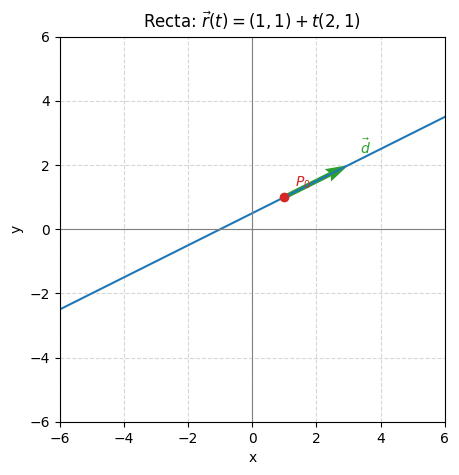

In [3]:
plot_recta_2d(P0_2d, d_2d, titulo=r"Recta: $\vec{r}(t) = (1,1) + t(2,1)$")

## 2. La recta en $\mathbb{R}^3$

En $\mathbb{R}^3$ una recta también queda determinada por un punto $P_0=(x_0,y_0,z_0)$ y un vector director $\vec{d}=(d_1,d_2,d_3)$.

**Ecuación vectorial:**
$$
\vec{r}(t) = P_0 + t\,\vec{d}
$$

**Ecuaciones paramétricas:**
$$
x = x_0 + t\,d_1, \qquad y = y_0 + t\,d_2, \qquad z = z_0 + t\,d_3
$$

**Ecuaciones simétricas** (si $d_1, d_2, d_3 \neq 0$), despejando $t$ de cada una:
$$
\frac{x-x_0}{d_1} = \frac{y-y_0}{d_2} = \frac{z-z_0}{d_3}
$$

A diferencia de $\mathbb{R}^2$, en $\mathbb{R}^3$ **no existe** una única ecuación general para una recta (una sola ecuación lineal en $\mathbb{R}^3$ describe un plano, no una recta); por eso se usan las formas vectorial, paramétrica o simétrica.

In [4]:
# Recta en R^3 que pasa por P0 = (0, 0, 0) con dirección d = (1, 2, 1)
P0_3d = np.array([0, 0, 0])
d_3d = np.array([1, 2, 1])

print("Vectorial: r(t) =", P0_3d, "+ t", d_3d)
print(f"Paramétricas: x = {P0_3d[0]}+t({d_3d[0]}), y = {P0_3d[1]}+t({d_3d[1]}), z = {P0_3d[2]}+t({d_3d[2]})")
print(f"Simétricas: (x-{P0_3d[0]})/{d_3d[0]} = (y-{P0_3d[1]})/{d_3d[1]} = (z-{P0_3d[2]})/{d_3d[2]}")

# Punto de la recta para t = 3
t_val = 3
punto_t = P0_3d + t_val * d_3d
print(f"Punto en t={t_val}:", punto_t)

Vectorial: r(t) = [0 0 0] + t [1 2 1]
Paramétricas: x = 0+t(1), y = 0+t(2), z = 0+t(1)
Simétricas: (x-0)/1 = (y-0)/2 = (z-0)/1
Punto en t=3: [3 6 3]


### Dibujo: recta en $\mathbb{R}^3$

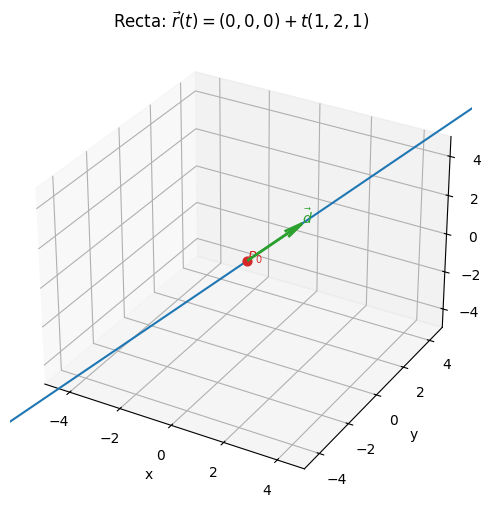

In [5]:
plot_recta_3d(P0_3d, d_3d, titulo=r"Recta: $\vec{r}(t) = (0,0,0) + t(1,2,1)$")

## 3. El plano en $\mathbb{R}^3$

Un plano queda determinado por un **punto** $P_0=(x_0,y_0,z_0)$ y un **vector normal** $\vec{n}=(A,B,C)$, perpendicular a todo el plano.

**Ecuación vectorial (normal-punto).** Un punto $P=(x,y,z)$ está en el plano si $\vec{n}\cdot(P-P_0)=0$:
$$
\vec{n}\cdot(\vec{r}-P_0) = 0
$$

**Ecuación general (cartesiana):**
$$
A(x-x_0) + B(y-y_0) + C(z-z_0) = 0 \quad \Longrightarrow \quad Ax+By+Cz+D=0,\ \ D=-(Ax_0+By_0+Cz_0)
$$

**Plano a partir de dos vectores directores.** Si el plano pasa por $P_0$ y contiene dos vectores no paralelos $\vec{u}, \vec{v}$ (por ejemplo, $\vec{u}=Q-P_0$, $\vec{v}=R-P_0$ con $P_0,Q,R$ tres puntos no colineales), su normal es
$$
\vec{n} = \vec{u}\times\vec{v}
$$

y la ecuación paramétrica del plano es $\vec{r}(s,t) = P_0 + s\,\vec{u} + t\,\vec{v}$.

In [6]:
# Plano que pasa por P0 = (0,0,0) con normal n = (1,1,1)
P0_plano = np.array([0, 0, 0])
n_plano = np.array([1, 1, 1])

D = -np.dot(n_plano, P0_plano)
print(f"General: {n_plano[0]}x + {n_plano[1]}y + {n_plano[2]}z + {D} = 0")

# Plano a partir de tres puntos
P, Q, R = np.array([1, 0, 0]), np.array([0, 1, 0]), np.array([0, 0, 1])
u, v = Q - P, R - P
n_de_3_puntos = np.cross(u, v)
D2 = -np.dot(n_de_3_puntos, P)
print("\nPlano por P=(1,0,0), Q=(0,1,0), R=(0,0,1):")
print("n = u x v =", n_de_3_puntos)
print(f"General: {n_de_3_puntos[0]}x + {n_de_3_puntos[1]}y + {n_de_3_puntos[2]}z + {D2} = 0")

General: 1x + 1y + 1z + 0 = 0

Plano por P=(1,0,0), Q=(0,1,0), R=(0,0,1):
n = u x v = [1 1 1]
General: 1x + 1y + 1z + -1 = 0


### Dibujo: plano en $\mathbb{R}^3$

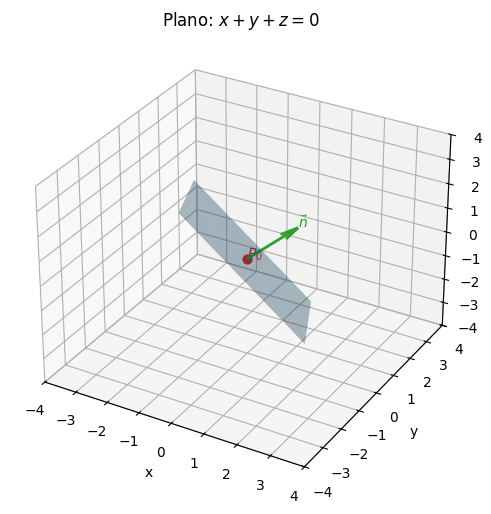

In [7]:
plot_plano_3d(P0_plano, n_plano, titulo=r"Plano: $x+y+z=0$")

## 4. Distancias

| Distancia | Fórmula |
|---|---|
| Entre dos puntos $P,Q \in \mathbb{R}^n$ | $d(P,Q) = \lVert Q-P \rVert$ |
| De un punto $Q$ a una recta en $\mathbb{R}^2$ (recta $Ax+By+C=0$) | $d = \dfrac{\lvert Ax_1+By_1+C \rvert}{\sqrt{A^2+B^2}}$ |
| De un punto $Q$ a una recta $P_0+t\vec{d}$ (general, $\mathbb{R}^2$ o $\mathbb{R}^3$) | $d = \dfrac{\lVert (Q-P_0)\times \vec{d} \rVert}{\lVert \vec{d} \rVert}$ *(en $\mathbb{R}^2$, usando el "cruz 2D" $u_1v_2-u_2v_1$)* |
| De un punto $Q$ a un plano $Ax+By+Cz+D=0$ | $d = \dfrac{\lvert Ax_1+By_1+Cz_1+D \rvert}{\sqrt{A^2+B^2+C^2}}$ |
| Entre dos rectas paralelas | Se toma un punto de una y se calcula su distancia a la otra recta |
| Entre dos planos paralelos | Se toma un punto de uno y se calcula su distancia al otro plano |
| Entre dos rectas que se cruzan (alabeadas) en $\mathbb{R}^3$ | $d = \dfrac{\lvert (\vec{d_1}\times\vec{d_2})\cdot (P_2-P_1) \rvert}{\lVert \vec{d_1}\times\vec{d_2} \rVert}$ |

La idea geométrica común es siempre la misma: la distancia mínima de un punto a una recta o a un plano se mide **perpendicularmente**, a lo largo de la dirección normal.

### 4.1 Distancia de un punto a una recta en $\mathbb{R}^2$

Usamos la recta $\vec{r}(t)=(1,1)+t(2,1)$ (equivalente a $x-2y+1=0$) y el punto $Q=(5,0)$.

In [9]:
Q = np.array([5, 0])

# Método 1: fórmula con la ecuación general A x + B y + C = 0
dist_general = abs(A * Q[0] + B * Q[1] + C) / np.sqrt(A**2 + B**2)

# Método 2: proyección -> pie de la perpendicular sobre la recta P0 + t d
t_pie = np.dot(Q - P0_2d, d_2d) / np.dot(d_2d, d_2d)
pie = P0_2d + t_pie * d_2d
dist_proyeccion = np.linalg.norm(Q - pie)

print("Distancia (fórmula general)   =", dist_general)
print("Distancia (pie de la altura)  =", dist_proyeccion)
print("Pie de la perpendicular       =", pie)

Distancia (fórmula general)   = 2.6832815729997477
Distancia (pie de la altura)  = 2.6832815729997477
Pie de la perpendicular       = [3.8 2.4]


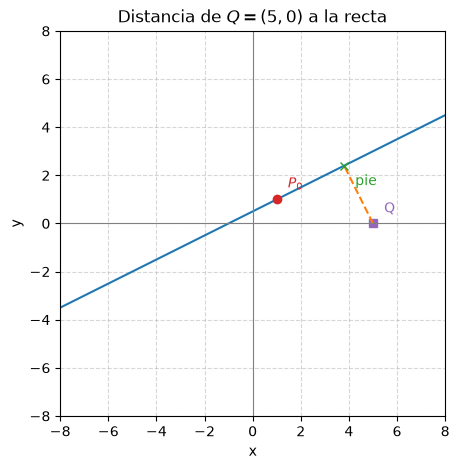

In [9]:
plot_distancia_punto_recta_2d(P0_2d, d_2d, Q, titulo=r"Distancia de $Q=(5,0)$ a la recta")

### 4.2 Distancia de un punto a una recta en $\mathbb{R}^3$

Usamos la recta $\vec{r}(t)=(0,0,0)+t(1,2,1)$ y el punto $Q_3=(3,0,0)$. La fórmula general con producto cruz también funciona en $\mathbb{R}^2$ tratando los vectores como elementos de $\mathbb{R}^3$ con tercera componente $0$.

In [10]:
Q3 = np.array([3, 0, 0])

dist_recta_3d = np.linalg.norm(np.cross(Q3 - P0_3d, d_3d)) / np.linalg.norm(d_3d)

# Verificación por pie de la perpendicular
t_pie_3d = np.dot(Q3 - P0_3d, d_3d) / np.dot(d_3d, d_3d)
pie_3d = P0_3d + t_pie_3d * d_3d
dist_verif_3d = np.linalg.norm(Q3 - pie_3d)

print("Distancia (producto cruz) =", dist_recta_3d)
print("Distancia (pie de altura) =", dist_verif_3d)

Distancia (producto cruz) = 2.738612787525831
Distancia (pie de altura) = 2.7386127875258306


### 4.3 Distancia de un punto a un plano

Usamos el plano $x+y+z=0$ (normal $\vec{n}=(1,1,1)$, punto $P_0=(0,0,0)$) y el punto $Q_p=(3,3,3)$.

In [11]:
Qp = np.array([3, 3, 3])

# Fórmula con la ecuación general Ax+By+Cz+D=0
dist_plano = abs(np.dot(n_plano, Qp) + D) / np.linalg.norm(n_plano)

# Verificación por pie de la perpendicular
t_pie_plano = np.dot(Qp - P0_plano, n_plano) / np.dot(n_plano, n_plano)
pie_plano = Qp - t_pie_plano * n_plano
dist_verif_plano = np.linalg.norm(Qp - pie_plano)

print("Distancia (fórmula general) =", dist_plano)
print("Distancia (pie de altura)   =", dist_verif_plano)
print("Pie de la perpendicular     =", pie_plano)

Distancia (fórmula general) = 5.196152422706632
Distancia (pie de altura)   = 5.196152422706632
Pie de la perpendicular     = [0. 0. 0.]


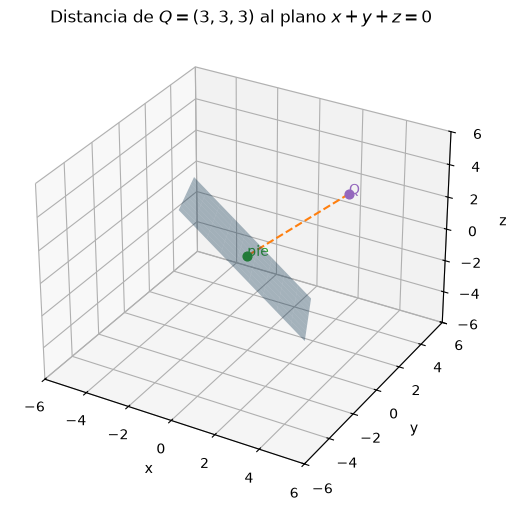

In [12]:
plot_distancia_punto_plano_3d(P0_plano, n_plano, Qp, titulo=r"Distancia de $Q=(3,3,3)$ al plano $x+y+z=0$")

### 4.4 Distancia entre dos rectas que se cruzan en $\mathbb{R}^3$

Dos rectas en $\mathbb{R}^3$ que no son paralelas y no se intersecan se llaman **alabeadas** (skew). La distancia mínima entre ellas se calcula proyectando el vector que une un punto de cada recta sobre la dirección común perpendicular a ambas, $\vec{d_1}\times\vec{d_2}$.

Consideremos $r_1(t) = (0,0,0) + t(1,0,0)$ y $r_2(s) = (0,1,1) + s(0,1,1)$.

In [12]:
P1, d1 = np.array([0, 0, 0]), np.array([1, 0, 0])
P2, d2 = np.array([0, 1, 1]), np.array([0, 1, 1])

n_comun = np.cross(d1, d2)
if np.allclose(n_comun, 0):
    print("Las rectas son paralelas: usar la distancia punto-recta.")
else:
    dist_alabeadas = abs(np.dot(n_comun, P2 - P1)) / np.linalg.norm(n_comun)
    print("d1 x d2 =", n_comun)
    print("Distancia entre las rectas alabeadas =", dist_alabeadas)

d1 x d2 = [ 0 -1  1]
Distancia entre las rectas alabeadas = 0.0


## 5. Resumen

- En $\mathbb{R}^2$ una recta se describe con un punto y un vector director (vectorial/paramétrica) o con la ecuación general $Ax+By+C=0$, cuyo vector normal es $\vec{n}=(A,B)$.
- En $\mathbb{R}^3$ una recta se describe con un punto y un vector director; no existe una única ecuación general, por lo que se usan las formas vectorial, paramétrica o simétrica.
- En $\mathbb{R}^3$ un plano se describe con un punto y un vector normal $\vec{n}$, dando la ecuación general $Ax+By+Cz+D=0$; también puede describirse con un punto y dos vectores directores no paralelos ($\vec{n}=\vec{u}\times\vec{v}$).
- La **distancia de un punto a una recta o a un plano** siempre se mide de forma perpendicular; se puede calcular con el **pie de la perpendicular** (proyección) o con fórmulas cerradas que usan la normal (en $\mathbb{R}^2$) o el producto cruz (en $\mathbb{R}^3$).
- La **distancia entre dos rectas o planos paralelos** se reduce a una distancia punto-recta o punto-plano.
- La **distancia entre dos rectas alabeadas** (que no se cruzan ni son paralelas) usa el vector $\vec{d_1}\times\vec{d_2}$, perpendicular a ambas direcciones.

## 6. Ejercicios

Resuelve a mano y luego verifica tus respuestas con `numpy` en una celda de código.

### A. Rectas en $\mathbb{R}^2$

1. Escribe la ecuación vectorial y paramétrica de la recta que pasa por $P_0=(2,-1)$ con dirección $\vec{d}=(3,4)$.
2. Encuentra la ecuación general $Ax+By+C=0$ de la recta anterior.
3. Encuentra la ecuación de la recta que pasa por los puntos $P=(1,2)$ y $Q=(4,8)$.
4. Determina el vector normal de la recta $2x-3y+6=0$.
5. ¿El punto $(1,1)$ pertenece a la recta $3x+2y-5=0$?

### B. Rectas en $\mathbb{R}^3$

6. Escribe las ecuaciones paramétricas y simétricas de la recta que pasa por $P_0=(1,0,2)$ con dirección $\vec{d}=(2,-1,3)$.
7. Encuentra la recta que pasa por $P=(0,0,0)$ y $Q=(1,1,1)$.
8. Determina si el punto $(3,-1,5)$ pertenece a la recta del ejercicio 6.
9. ¿Son paralelas las rectas con direcciones $(2,4,-2)$ y $(1,2,-1)$?

### C. Planos en $\mathbb{R}^3$

10. Encuentra la ecuación general del plano que pasa por $P_0=(1,1,1)$ con normal $\vec{n}=(2,-1,3)$.
11. Encuentra la ecuación del plano que pasa por los puntos $P=(1,0,0)$, $Q=(0,1,0)$ y $R=(0,0,2)$.
12. Determina si el punto $(2,2,2)$ pertenece al plano $x+y-z-2=0$.
13. Encuentra un vector normal al plano $3x-2y+z-7=0$.
14. ¿Son paralelos los planos $x+2y-z=1$ y $2x+4y-2z=5$?

### D. Distancias

15. Calcula la distancia del punto $(4,1)$ a la recta $3x-4y+2=0$.
16. Calcula la distancia del punto $(0,0)$ a la recta que pasa por $(1,1)$ con dirección $(1,-1)$.
17. Calcula la distancia del punto $(1,2,3)$ al plano $2x-y+2z-4=0$.
18. Calcula la distancia entre las rectas paralelas $x-2y+1=0$ y $x-2y+5=0$ (toma un punto de la primera y aplica la fórmula punto-recta con la segunda).
19. Calcula la distancia entre los planos paralelos $x+y+z=0$ y $x+y+z=6$.
20. Calcula la distancia entre las rectas alabeadas $r_1(t)=(1,0,0)+t(0,1,0)$ y $r_2(s)=(0,0,1)+s(1,0,0)$.
21. Verifica que el pie de la perpendicular del punto $(5,0)$ sobre la recta $(1,1)+t(2,1)$ coincide con el que calculaste a mano.

**Sugerencia:** define los puntos y vectores con `np.array`, usa `np.dot`, `np.cross` y `np.linalg.norm`, y reutiliza las funciones de graficación para visualizar cada ejercicio.

In [14]:
# Espacio para verificar tus respuestas con numpy
# Ejemplo (ejercicio 15):
# A, B, C = 3, -4, 2
# Q = np.array([4, 1])
# print(abs(A*Q[0] + B*Q[1] + C) / np.sqrt(A**2 + B**2))
